In [82]:
import pandas as pd
import numpy as np

In [83]:
df = pd.read_csv("Procurement KPI Analysis Dataset.csv")
df.head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
0,PO-00001,Alpha_Inc,17/10/2023,25/10/2023,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes
1,PO-00002,Delta_Logistics,25/4/2022,5/5/2022,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes
2,PO-00003,Gamma_Co,26/1/2022,15/2/2022,MRO,Delivered,910,95.51,92.26,41.0,Yes
3,PO-00004,Beta_Supplies,9/10/2022,28/10/2022,Packaging,Delivered,1344,99.85,95.52,112.0,Yes
4,PO-00005,Delta_Logistics,8/9/2022,20/9/2022,Raw Materials,Delivered,1180,64.07,60.53,171.0,No


In [84]:
df.shape

(777, 11)

In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PO_ID             777 non-null    str    
 1   Supplier          777 non-null    str    
 2   Order_Date        777 non-null    str    
 3   Delivery_Date     690 non-null    str    
 4   Item_Category     777 non-null    str    
 5   Order_Status      777 non-null    str    
 6   Quantity          777 non-null    int64  
 7   Unit_Price        777 non-null    float64
 8   Negotiated_Price  777 non-null    float64
 9   Defective_Units   641 non-null    float64
 10  Compliance        777 non-null    str    
dtypes: float64(3), int64(1), str(7)
memory usage: 66.9 KB


In [86]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Delivery_Date"] =pd.to_datetime(df["Delivery_Date"])

C:\Users\Win10Pro\AppData\Local\Temp\ipykernel_864\2374218418.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order_Date"] = pd.to_datetime(df["Order_Date"])
C:\Users\Win10Pro\AppData\Local\Temp\ipykernel_864\2374218418.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Delivery_Date"] =pd.to_datetime(df["Delivery_Date"])


In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   PO_ID             777 non-null    str           
 1   Supplier          777 non-null    str           
 2   Order_Date        777 non-null    datetime64[us]
 3   Delivery_Date     690 non-null    datetime64[us]
 4   Item_Category     777 non-null    str           
 5   Order_Status      777 non-null    str           
 6   Quantity          777 non-null    int64         
 7   Unit_Price        777 non-null    float64       
 8   Negotiated_Price  777 non-null    float64       
 9   Defective_Units   641 non-null    float64       
 10  Compliance        777 non-null    str           
dtypes: datetime64[us](2), float64(3), int64(1), str(5)
memory usage: 66.9 KB


In [88]:
df.isnull().sum()

PO_ID                 0
Supplier              0
Order_Date            0
Delivery_Date        87
Item_Category         0
Order_Status          0
Quantity              0
Unit_Price            0
Negotiated_Price      0
Defective_Units     136
Compliance            0
dtype: int64

In [89]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().mean()*100).round(3)
})

missing

,Missing_Count,Missing_Percentage
PO_ID,0,0.000
Supplier,0,0.000
Order_Date,0,0.000
Delivery_Date,87,11.197
Item_Category,0,0.000
Order_Status,0,0.000
Quantity,0,0.000
Unit_Price,0,0.000
Negotiated_Price,0,0.000
Defective_Units,136,17.503


In [90]:
df.duplicated().sum()

0

In [91]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Order_Date,777,2022-12-28 23:15:31.274131,2022-01-01 00:00:00,2022-07-02 00:00:00,2022-12-24 00:00:00,2023-07-07 00:00:00,2024-01-01 00:00:00,NaN
Delivery_Date,690,2023-01-12 03:16:10.434782,2022-01-06 00:00:00,2022-07-19 18:00:00,2023-01-19 12:00:00,2023-07-18 00:00:00,2024-01-12 00:00:00,NaN
Quantity,777.0,1094.660232,51.0,615.0,1075.0,1548.0,5000.0,647.844551
Unit_Price,777.0,58.283822,10.84,33.29,58.95,83.13,109.17,28.101315
Negotiated_Price,777.0,53.660721,9.27,30.46,53.8,76.55,107.39,26.09493
Defective_Units,641.0,74.803432,0.0,26.0,49.0,100.0,321.0,69.18787


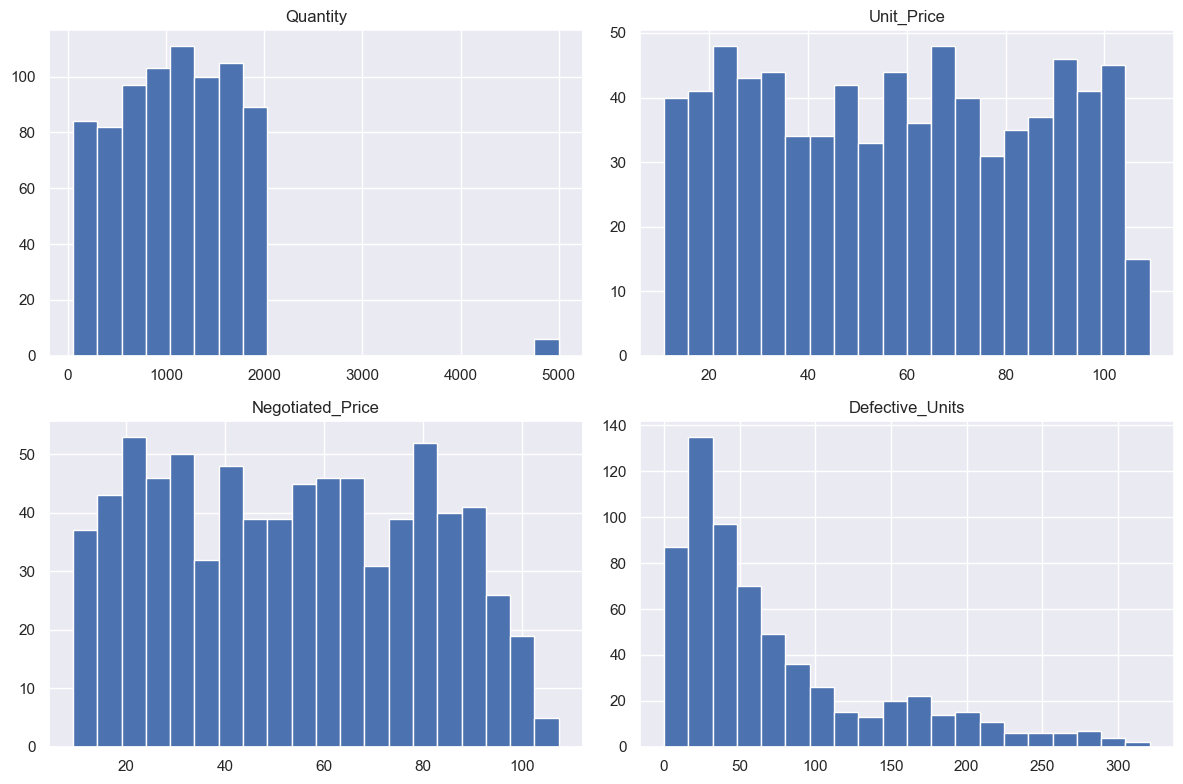

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme(style="darkgrid")

df[['Quantity','Unit_Price', 'Negotiated_Price', 'Defective_Units']].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

In [93]:
Q1 =df['Quantity'].quantile(0.25)
Q3 =df['Quantity'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 -1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Quantity'] < lower) |
    (df['Quantity'] > upper)
]

outliers

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
10,PO-00011,Epsilon_Group,2022-03-31,2022-04-15,Raw Materials,Delivered,5000,78.49,73.68,18.0,Yes
11,PO-00012,Beta_Supplies,2023-08-28,2023-09-11,Raw Materials,Delivered,5000,88.96,86.58,115.0,Yes
12,PO-00013,Beta_Supplies,2023-03-09,2023-03-26,Electronics,Pending,5000,86.74,74.86,51.0,Yes
13,PO-00014,Beta_Supplies,2022-02-02,NaT,MRO,Delivered,5000,18.30,16.88,NaN,Yes
14,PO-00015,Delta_Logistics,2022-01-31,2022-02-18,Electronics,Pending,5000,54.50,48.45,22.0,Yes
15,PO-00016,Beta_Supplies,2022-04-06,2022-04-21,Packaging,Delivered,5000,15.41,15.12,NaN,Yes


In [94]:
df.groupby('Item_Category')['Defective_Units'].agg(
    ['count', 'median', 'mean' , 'std']
).round(3)

,count,median,mean,std
Item_Category,,,,
Electronics,128,43.0,70.164,68.858
MRO,137,48.0,71.102,61.935
Office Supplies,142,55.5,79.106,69.728
Packaging,119,48.0,70.185,65.561
Raw Materials,115,56.0,83.843,79.906


In [95]:
df.groupby('Supplier')['Defective_Units'].agg(
    ['count','median', 'mean', 'std']
).round(3)

,count,median,mean,std
Supplier,,,,
Alpha_Inc,113,24.0,24.044,16.514
Beta_Supplies,132,101.5,104.833,57.761
Delta_Logistics,127,153.0,154.945,86.345
Epsilon_Group,141,32.0,33.206,19.173
Gamma_Co,128,56.5,54.953,25.858


In [96]:
df.groupby(
    ['Supplier', 'Item_Category']
    )['Defective_Units'].agg(
        ['count', 'median', 'mean', 'std']
    ).round(3)

count  median     mean     std
Supplier        Item_Category                                  
Alpha_Inc       Electronics         20    27.0   29.100  19.735
                MRO                 31    22.0   23.645  13.480
                Office Supplies     24    20.5   22.167  21.023
                Packaging           21    26.0   26.095  12.255
                Raw Materials       17    14.0   18.941  14.562
Beta_Supplies   Electronics         29    84.0   90.000  58.635
                MRO                 22   117.0  116.455  54.983
                Office Supplies     34    97.0  104.471  57.454
                Packaging           23   103.0  102.522  56.413
                Raw Materials       24   116.5  114.833  61.318
Delta_Logistics Electronics         24   148.0  149.958  97.534
                MRO                 24   161.0  145.250  78.012
                Office Supplies     34   149.5  148.618  77.953
                Packaging           18   182.0  164.389  88.920
                Raw Materials       27   171.0  169.667  94.870
Epsilon_Group   Electronics         32    31.5   33.625  23.222
                MRO                 34    36.5   35.882  13.644
                Office Supplies     28    33.0   35.143  22.827
                Packaging           31    31.0   30.742  17.376
                Raw Materials       16    25.0   28.062  17.342
Gamma_Co        Electronics         23    43.0   48.435  22.817
                MRO                 26    74.0   66.923  26.063
                Office Supplies     22    52.5   50.545  27.440
                Packaging           26    56.5   59.000  24.168
                Raw Materials       31    49.0   49.484  25.550

In [97]:
df[df['Defective_Units'].isna()]\
.groupby(['Supplier', 'Item_Category'])\
.size()

Supplier         Item_Category  
Alpha_Inc        Electronics         2
                 MRO                 4
                 Office Supplies    15
                 Packaging           6
                 Raw Materials       1
Beta_Supplies    Electronics         3
                 MRO                 4
                 Office Supplies     7
                 Packaging           7
                 Raw Materials       3
Delta_Logistics  Electronics         9
                 MRO                10
                 Office Supplies     3
                 Packaging          11
                 Raw Materials      11
Epsilon_Group    Electronics         4
                 MRO                 5
                 Office Supplies     6
                 Packaging           3
                 Raw Materials       7
Gamma_Co         Electronics         6
                 MRO                 4
                 Office Supplies     1
                 Packaging           2
                 Raw Materials 

In [98]:
missing_rows = df[df['Defective_Units'].isna()].copy()
missing_rows

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes
13,PO-00014,Beta_Supplies,2022-02-02,NaT,MRO,Delivered,5000,18.30,16.88,NaN,Yes
15,PO-00016,Beta_Supplies,2022-04-06,2022-04-21,Packaging,Delivered,5000,15.41,15.12,NaN,Yes
17,PO-00018,Epsilon_Group,2022-08-27,2022-09-04,Raw Materials,Delivered,921,51.48,50.61,NaN,Yes
19,PO-00020,Delta_Logistics,2023-09-09,2023-09-24,Raw Materials,Delivered,180,45.74,38.89,NaN,No
...,...,...,...,...,...,...,...,...,...,...,...
731,PO-00732,Delta_Logistics,2022-03-25,2022-04-11,Packaging,Partially Delivered,1350,85.06,82.34,NaN,No
739,PO-00740,Delta_Logistics,2022-03-12,2022-03-19,MRO,Delivered,241,87.42,82.15,NaN,Yes
750,PO-00751,Delta_Logistics,2023-04-30,NaT,Electronics,Delivered,1809,13.58,12.68,NaN,No
752,PO-00753,Epsilon_Group,2022-04-28,NaT,MRO,Delivered,1853,21.92,20.72,NaN,Yes


In [99]:
Q1 = df['Defective_Units'].quantile(0.25)
Q3 = df['Defective_Units'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower:", lower)
print("Upper:", upper)

Lower: -85.0
Upper: 211.0


In [100]:
df[df['Defective_Units'] > upper]['Defective_Units'].count()

40

In [101]:
df[df['Defective_Units'] > upper]

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes
53,PO-00054,Delta_Logistics,2022-03-22,2022-03-28,Office Supplies,Cancelled,1640,77.92,76.41,262.0,No
85,PO-00086,Delta_Logistics,2023-09-16,2023-09-24,Office Supplies,Delivered,1635,56.91,54.37,262.0,No
86,PO-00087,Delta_Logistics,2023-10-13,2023-10-23,Raw Materials,Delivered,1945,46.19,40.12,278.0,No
87,PO-00088,Delta_Logistics,2022-06-25,2022-07-10,MRO,Partially Delivered,1461,64.09,63.39,228.0,No
132,PO-00133,Delta_Logistics,2022-04-04,2022-04-22,Electronics,Cancelled,1930,65.52,56.90,282.0,Yes
148,PO-00149,Beta_Supplies,2023-07-21,NaT,Packaging,Delivered,1846,13.72,12.62,216.0,Yes
170,PO-00171,Delta_Logistics,2023-10-17,2023-10-21,Packaging,Delivered,1620,36.73,33.45,235.0,No
199,PO-00200,Delta_Logistics,2023-05-02,2023-05-17,Raw Materials,Delivered,1973,59.73,54.95,291.0,Yes
225,PO-00226,Delta_Logistics,2023-08-26,2023-09-10,Office Supplies,Cancelled,1629,21.51,19.41,250.0,No


In [102]:
df['Defective_Units'] = df['Defective_Units'].fillna(
    df.groupby(['Supplier', 'Item_Category'])['Defective_Units']
    .transform('median')
)

In [103]:
print(df['Defective_Units'].isna().sum())

0


In [104]:
df.isna().sum()

PO_ID                0
Supplier             0
Order_Date           0
Delivery_Date       87
Item_Category        0
Order_Status         0
Quantity             0
Unit_Price           0
Negotiated_Price     0
Defective_Units      0
Compliance           0
dtype: int64

In [105]:
df[df['Delivery_Date'].isna()]['Order_Status'].value_counts()

Order_Status
Delivered              68
Cancelled               8
Pending                 6
Partially Delivered     5
Name: count, dtype: int64

In [106]:
df[df['Delivery_Date'].isna()]\
.groupby('Supplier')\
.size()

Supplier
Alpha_Inc          24
Beta_Supplies      13
Delta_Logistics    20
Epsilon_Group      17
Gamma_Co           13
dtype: int64

In [107]:
df[df['Delivery_Date'].isna()]\
.groupby(['Supplier', 'Item_Category'])\
.size()

Supplier         Item_Category  
Alpha_Inc        Electronics        2
                 MRO                5
                 Office Supplies    8
                 Packaging          4
                 Raw Materials      5
Beta_Supplies    Electronics        2
                 MRO                1
                 Office Supplies    3
                 Packaging          4
                 Raw Materials      3
Delta_Logistics  Electronics        5
                 MRO                4
                 Office Supplies    3
                 Packaging          1
                 Raw Materials      7
Epsilon_Group    Electronics        1
                 MRO                5
                 Office Supplies    7
                 Packaging          2
                 Raw Materials      2
Gamma_Co         Electronics        3
                 Office Supplies    3
                 Packaging          2
                 Raw Materials      5
dtype: int64

In [108]:
df[df['Delivery_Date'].isna()]\
.groupby(['Order_Status', 'Supplier', 'Item_Category'])\
.size()

Order_Status         Supplier         Item_Category  
Cancelled            Alpha_Inc        Electronics        1
                     Beta_Supplies    Electronics        2
                                      Raw Materials      1
                     Epsilon_Group    Office Supplies    1
                                      Packaging          2
                                      Raw Materials      1
Delivered            Alpha_Inc        Electronics        1
                                      MRO                4
                                      Office Supplies    6
                                      Packaging          3
                                      Raw Materials      4
                     Beta_Supplies    MRO                1
                                      Office Supplies    3
                                      Packaging          4
                                      Raw Materials      2
                     Delta_Logistics  Electronics        5
  

In [109]:
df['Delivery_Days'] = (
    df['Delivery_Date'] -df['Order_Date']
).dt.days

In [110]:
delivery_df = df[
    df['Order_Status'].isin(['Delivered', 'Partially Delivered'])
]

In [111]:
delivery_df['Delivery_Days'].describe()

count    560.000000
mean      10.555357
std        5.709779
min       -5.000000
25%        6.000000
50%       11.000000
75%       15.000000
max       20.000000
Name: Delivery_Days, dtype: float64

In [112]:
(delivery_df['Delivery_Days']<0).sum()

1

In [113]:
delivery_df[delivery_df['Delivery_Days']<0][
    ['PO_ID','Supplier', 'Order_Date',
     'Delivery_Date', 'Item_Category',
     'Order_Status', 'Delivery_Days']
]

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Delivery_Days
100,PO-00101,Alpha_Inc,2022-02-27,2022-02-22,Office Supplies,Delivered,-5.0


In [114]:
df.loc[df['Delivery_Days'] < 0, 'Delivery_Days'] = np.nan

In [115]:
df.loc[df['Delivery_Days'].isna(), 'Delivery_Date'] = None

In [116]:
df['Was_Missing'] = df['Delivery_Date'].isna()\
    & df['Order_Status'].isin(['Delivered', 'Partially Delivered'])

In [117]:
valid_delivery = df[
df['Order_Status'].isin(['Delivered', 'Partially Delivered'])]
df['Delivery_Days'].notna() &(df['Delivery_Days'] >= 0)

median_days = valid_delivery.groupby(
    ['Supplier', 'Item_Category']
)['Delivery_Days'].median()

overall_median = valid_delivery['Delivery_Days'].median()

In [118]:
def fill_date(row):
    if pd.isna(row['Delivery_Date']) and row['Order_Status'] in ['Delivered', 'Partially Delivered']:

        days = median_days.get(
            (row['Supplier'], row['Item_Category']),
            overall_median
        )
        return row['Order_Date'] + pd.Timedelta(days=days)
    return row['Delivery_Date']

In [119]:
df['Delivery_Date'] = df.apply(fill_date, axis=1)

In [120]:
df[df['Delivery_Date'].isna()]['Order_Status'].value_counts()

Order_Status
Cancelled    8
Pending      6
Name: count, dtype: int64

In [121]:
print((df['Delivery_Days'] < 0).sum(), "แถวติดลบ")
print(df['Delivery_Days'].isna().sum(), "แถว NaN")

0 แถวติดลบ
88 แถว NaN


In [122]:
df.isnull().sum()

PO_ID                0
Supplier             0
Order_Date           0
Delivery_Date       14
Item_Category        0
Order_Status         0
Quantity             0
Unit_Price           0
Negotiated_Price     0
Defective_Units      0
Compliance           0
Delivery_Days       88
Was_Missing          0
dtype: int64

In [123]:
df.drop(columns=['Delivery_Days'], inplace=True)

In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   PO_ID             777 non-null    str           
 1   Supplier          777 non-null    str           
 2   Order_Date        777 non-null    datetime64[us]
 3   Delivery_Date     763 non-null    datetime64[us]
 4   Item_Category     777 non-null    str           
 5   Order_Status      777 non-null    str           
 6   Quantity          777 non-null    int64         
 7   Unit_Price        777 non-null    float64       
 8   Negotiated_Price  777 non-null    float64       
 9   Defective_Units   777 non-null    float64       
 10  Compliance        777 non-null    str           
 11  Was_Missing       777 non-null    bool          
dtypes: bool(1), datetime64[us](2), float64(3), int64(1), str(5)
memory usage: 67.7 KB


In [127]:
df.to_csv('Procurement_KPI_Analysis_Cleaned.csv', index=False)
print("Saved!")

Saved!
